In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('diabetes_dataset.csv')

In [3]:
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
print(df.shape)

(768, 9)


In [5]:
print(df['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [9]:
X = df.drop(columns='Outcome')
y = df['Outcome']

In [10]:
print(X)
print(y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6    148.0           72.0           35.0      NaN  33.6   
1              1     85.0           66.0           29.0      NaN  26.6   
2              8    183.0           64.0            NaN      NaN  23.3   
3              1     89.0           66.0           23.0     94.0  28.1   
4              0    137.0           40.0           35.0    168.0  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10    101.0           76.0           48.0    180.0  32.9   
764            2    122.0           70.0           27.0      NaN  36.8   
765            5    121.0           72.0           23.0    112.0  26.2   
766            1    126.0           60.0            NaN      NaN  30.1   
767            1     93.0           70.0           31.0      NaN  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [11]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.643863,70.877339,27.235457,130.287879,30.859674,0.429734,31.190000
1,4.865672,142.319549,75.321429,33.000000,206.846154,35.406767,0.550500,37.067164


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [15]:
''' MODELS USED
1) Logistic Regression (LR)
2) Support Vector Machine (SVM – Linear Kernel)
3) Random Forest (RF)'''

' MODELS USED\n1) Logistic Regression (LR)\n2) Support Vector Machine (SVM – Linear Kernel)\n3) Random Forest (RF)'

In [16]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.7337662337662337


In [17]:
svm_model = SVC(kernel='linear', class_weight='balanced', probability=True)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", acc_svm)

SVM Accuracy: 0.7272727272727273


In [18]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf.fit(X_train_imputed, y_train)

y_pred_rf = rf.predict(X_test_imputed)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.7402597402597403


In [19]:
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest"],
    "Accuracy": [acc_lr, acc_svm, acc_rf]
})
print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.733766
1                  SVM  0.727273
2        Random Forest  0.740260


In [20]:
print("Confusion Matrix (RF):")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report (RF):")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix (RF):
[[84 16]
 [24 30]]

Classification Report (RF):
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



In [21]:
'''TN = 84
84 non-diabetic people were correctly predicted as non-diabetic.
FP = 16
16 non-diabetic people were wrongly predicted as diabetic (false alarm).
FN = 24
24 diabetic people were wrongly predicted as non-diabetic (missed cases – dangerous in healthcare).
TP = 30
30 diabetic people were correctly predicted as diabetic.'''

'TN = 84\n84 non-diabetic people were correctly predicted as non-diabetic.\nFP = 16\n16 non-diabetic people were wrongly predicted as diabetic (false alarm).\nFN = 24\n24 diabetic people were wrongly predicted as non-diabetic (missed cases – dangerous in healthcare).\nTP = 30\n30 diabetic people were correctly predicted as diabetic.'

In [22]:
input_data = (7,100,0,0,0,30,0.484,32)
input_df = pd.DataFrame([input_data], columns=X.columns)

# Step 1: Impute
input_imputed = imputer.transform(input_df)

# Step 2: Predict with RF (no scaling)
pred_rf = rf.predict(input_imputed)
print("RF Result:", "DIABETIC" if pred_rf[0] == 1 else "NOT DIABETIC")

# Predict with LR/SVM (scaled)
input_scaled = scaler.transform(input_imputed)
pred_lr = lr.predict(input_scaled)
pred_svm = svm_model.predict(input_scaled)

print("LR Result:", "DIABETIC" if pred_lr[0] == 1 else "NOT DIABETIC")
print("SVM Result:", "DIABETIC" if pred_svm[0] == 1 else "NOT DIABETIC")

RF Result: NOT DIABETIC
LR Result: NOT DIABETIC
SVM Result: NOT DIABETIC


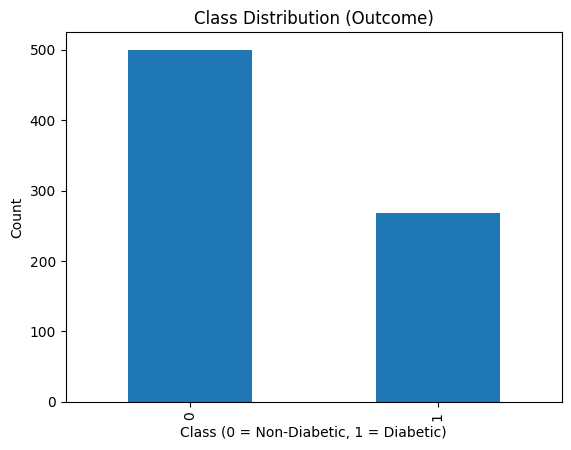

In [23]:
import matplotlib.pyplot as plt

plt.figure()
df['Outcome'].value_counts().plot(kind='bar')
plt.title('Class Distribution (Outcome)')
plt.xlabel('Class (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Count')
plt.show()

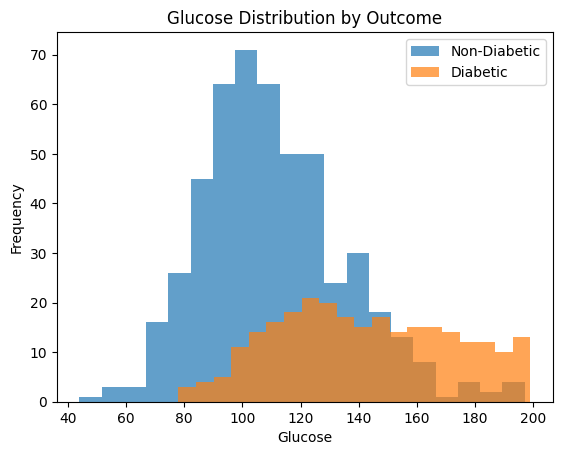

In [24]:
plt.figure()
plt.hist(df[df['Outcome'] == 0]['Glucose'], bins=20, alpha=0.7, label='Non-Diabetic')
plt.hist(df[df['Outcome'] == 1]['Glucose'], bins=20, alpha=0.7, label='Diabetic')
plt.title('Glucose Distribution by Outcome')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.legend()
plt.show()